# Step 11 — HFSS results in, amplifier assessment out

This notebook analyzes the selected, fitted HFSS unit cells. It does five things:

1. Validates the two fitted unit-cell rows.
2. Builds the complete periodic KI-TWPA.
3. Calculates passive transmission and dispersion.
4. Searches pump settings and calculates gain in 4–8 GHz.
5. Writes a machine-readable pass/fail report.

The selected geometry retains the published 12 µm and 3.9 µm stub arms. Its
fitted impedances are 43.09 Ω and 70.20 Ω. The nominal 48 Ω and 78 Ω values are
kept as reference targets, but are not substituted for the HFSS extraction.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "code" else Path.cwd()
CODE = ROOT / "code"
if str(CODE) not in sys.path:
    sys.path.insert(0, str(CODE))

from twpasolver import TWPAnalysis
from twpa_project_utils import (
    add_faramarzi_4wm, build_twpa_from_hfss, cell_profile,
    current_to_dbm, environment_metadata, gain_metrics, result_dir,
    save_curve, save_figure, save_json, save_matrix, save_model_bundle,
)

plt.style.use("seaborn-v0_8-whitegrid")
OUT = result_dir("step_11_hfss_imported_amplifier")

# This run requires the fitted HFSS data and refuses placeholder inputs.
ALLOW_PLACEHOLDER = False
CELL_CSV = ROOT / "hfss_inputs" / "hfss_cell_parameters.csv"
CONFIG_JSON = ROOT / "hfss_inputs" / "amplifier_config.json"

twpa, provenance = build_twpa_from_hfss(
    CELL_CSV, CONFIG_JSON, allow_placeholder=ALLOW_PLACEHOLDER
)
config = provenance["amplifier_config"]
cells_in = provenance["cells"]
save_json(OUT / "environment.json", environment_metadata())
save_json(OUT / "input_provenance.json", provenance)
save_model_bundle("hfss_imported_amplifier", twpa, provenance, ["HFSS handoff"])

print("INPUT STATUS:", provenance["status"])
print("HFSS validated:", provenance["cell_input"]["hfss_validated"])
print("Total cells:", f"{twpa.N_tot:,}")
print("Pump current:", f"{twpa.Ip0*1e6:.2f} microamp")
print("Equivalent 50-ohm pump power:", f"{float(current_to_dbm(twpa.Ip0)):.2f} dBm")
if provenance["warning"]:
    print("WARNING:", provenance["warning"])

INPUT STATUS: HFSS extracted
HFSS validated: True
Total cells: 40,800
Pump current: 100.00 microamp
Equivalent 50-ohm pump power: -36.02 dBm


## 1. Inspect the imported cells

The rectangular plot is the real pattern sent to `twpasolver`: unloaded cells,
a short loaded section, then unloaded cells again. The table is the audit trail
for the values that created it.

unloaded {'cell_type': 'unloaded', 'source': 'HFSS', 'stub_length_um': 12.0, 'L_pH': 55.293422258173955, 'C_fF': 29.780743113650452, 'Lf_pH': 123.846759188166, 'loss_tangent': 0.0, 'Z0_ohm': 43.08925347829123, 'fit_s21_rmse_db': 0.0005798699397446769, 'fit_phase_rmse_deg': 0.00535704728634735}
loaded {'cell_type': 'loaded', 'source': 'HFSS', 'stub_length_um': 3.9, 'L_pH': 54.102868806472884, 'C_fF': 10.978262398510854, 'Lf_pH': 49.277609882912536, 'loss_tangent': 0.0, 'Z0_ohm': 70.20100727735449, 'fit_s21_rmse_db': 1.5266710872876778e-05, 'fit_phase_rmse_deg': 0.002501306531699172}
HFSS acceptance gates: {'unloaded_Z0_selected_43p09ohm_pm5pct': True, 'loaded_Z0_selected_70p20ohm_pm5pct': True, 'impedance_ratio_selected_1p629_pm5pct': True, 'S21_fit_rmse_below_0p5db': True, 'phase_fit_rmse_below_5deg': True}


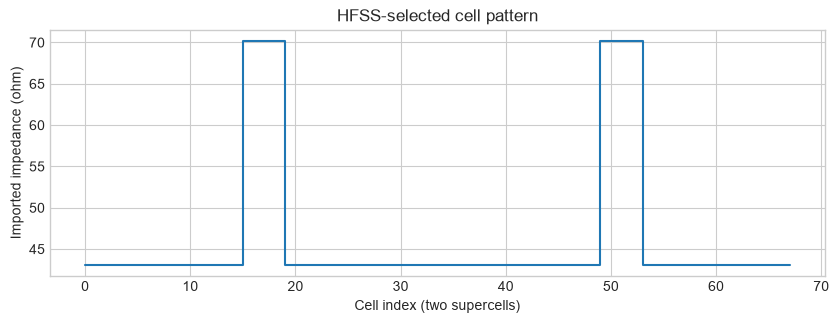

In [2]:
for role, row in cells_in.items():
    print(role, row)
print("HFSS acceptance gates:", provenance["cell_input"]["acceptance_checks"])

side = int(config["unloaded_cells_each_side"])
loaded = int(config["loaded_cells"])
x, impedance = cell_profile(
    [cells_in["unloaded"]["Z0_ohm"], cells_in["loaded"]["Z0_ohm"], cells_in["unloaded"]["Z0_ohm"]],
    [side, loaded, side],
    repeats=2,
)
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.step(x, impedance, where="post")
ax.set(xlabel="Cell index (two supercells)", ylabel="Imported impedance (ohm)", title="HFSS-selected cell pattern")
save_curve(OUT / "01_imported_cell_profile.csv", cell_index=x, impedance_ohm=impedance)
save_figure(fig, OUT, "01_imported_cell_profile")
plt.show()

## 2. Passive line: transmission, dispersion, and stopband

This calculation has no parametric gain yet. It checks whether the repeated
geometry produces the intended stopband and whether passive loss is acceptable.
If this part is wrong, pump optimization should not be trusted.

[INFO|2026-08-10 14:16:02]: Computing base parameters.


[INFO|2026-08-10 14:16:03]: Built symbolic expressions for 3 modes


[INFO|2026-08-10 14:16:03]: Independent modes: {'p', 's'}


[INFO|2026-08-10 14:16:03]: Built symbolic expressions for 3 modes


[INFO|2026-08-10 14:16:03]: Independent modes: {'p', 's'}


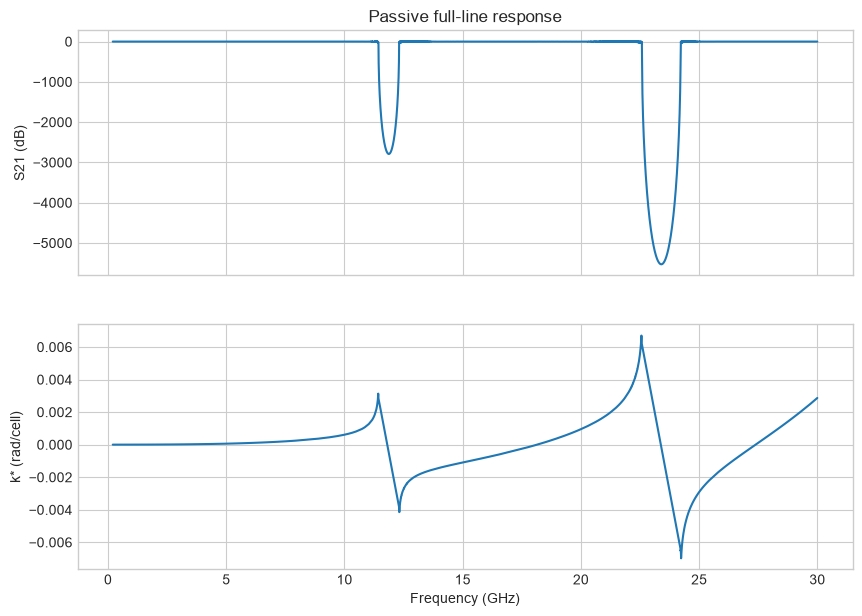

Stopband estimate (GHz): [22.58000000000002, 24.21600000000002]


In [3]:
analysis = TWPAnalysis(
    twpa=twpa,
    f_arange=(
        config["base_frequency_start_GHz"],
        config["base_frequency_stop_GHz"],
        config["base_frequency_step_GHz"],
    ),
    unit="GHz",
)
analysis.update_base_data()
freqs = np.asarray(analysis.data["freqs"])

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(freqs, analysis.data["S21_db"])
axes[0].set(ylabel="S21 (dB)", title="Passive full-line response")
axes[1].plot(freqs, analysis.data["k_star"])
axes[1].set(xlabel="Frequency (GHz)", ylabel="k* (rad/cell)")
save_curve(
    OUT / "02_passive_response.csv",
    frequency_GHz=freqs,
    S21_db=analysis.data["S21_db"],
    k_star=analysis.data["k_star"],
)
save_figure(fig, OUT, "02_passive_response")
plt.show()
print("Stopband estimate (GHz):", analysis.data.get("stopband_freqs"))

## 3. Pump search and gain map

For 3WM the solver uses $f_i=f_p-f_s$ and requires nonzero DC bias. For 4WM it
uses $f_i=2f_p-f_s$, sets DC bias to zero, and activates the extended 4WM mode
array. Every reported result retains the chosen mixing process in its metadata.

[INFO|2026-08-10 14:16:03]: Running gain


[INFO|2026-08-10 14:16:10]: Running gain


[INFO|2026-08-10 14:16:10]: Data for 'gain' output already present in analysis data, will be overwritten.


[INFO|2026-08-10 14:16:10]: Running gain


[INFO|2026-08-10 14:16:10]: Data for 'gain' output already present in analysis data, will be overwritten.


...

[INFO|2026-08-10 14:16:10]: Data for 'gain' output already present in analysis data, will be overwritten.


[INFO|2026-08-10 14:16:10]: Running gain


[INFO|2026-08-10 14:16:10]: Data for 'gain' output already present in analysis data, will be overwritten.


[INFO|2026-08-10 14:16:10]: Running gain


[INFO|2026-08-10 14:16:10]: Data for 'gain' output already present in analysis data, will be overwritten.


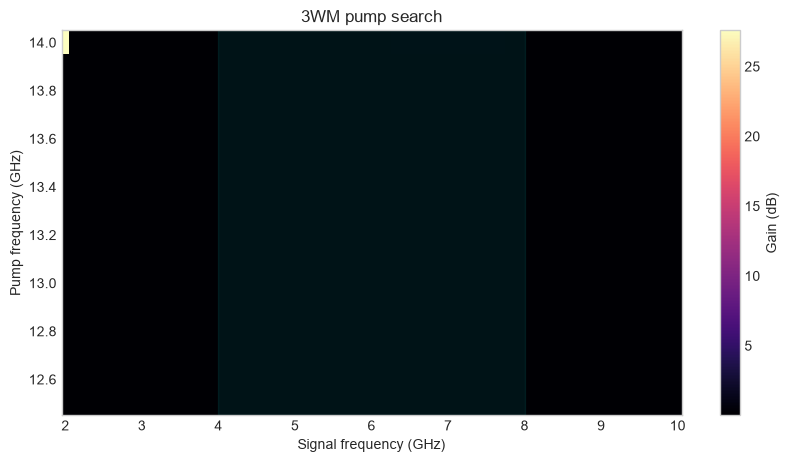

In [4]:
pumps = np.arange(
    config["pump_scan_start_GHz"],
    config["pump_scan_stop_GHz"] + config["pump_scan_step_GHz"] / 2,
    config["pump_scan_step_GHz"],
)
signals = np.arange(
    config["signal_start_GHz"],
    config["signal_stop_GHz"] + config["signal_step_GHz"] / 2,
    config["signal_step_GHz"],
)
process = config["mixing_process"].upper()
gain_rows = []

if process == "3WM":
    if twpa.Idc == 0:
        raise ValueError("3WM requires nonzero Idc_A")
    model = "minimal_3wm"
    mode_name = "basic_3wm"
elif process == "4WM":
    if twpa.Idc != 0:
        raise ValueError("Set Idc_A=0 for the pure 4WM comparison")
    model = "general_ideal"
    mode_name = add_faramarzi_4wm(analysis, "hfss_4wm")
else:
    raise ValueError("mixing_process must be 3WM or 4WM")

for pump in pumps:
    idlers = pump - signals if process == "3WM" else 2 * pump - signals
    if idlers.min() < freqs.min() or idlers.max() > freqs.max():
        raise ValueError(f"Generated idler is outside base data for pump {pump} GHz")
    result = analysis.gain(
        signals,
        pump=float(pump),
        Is0=float(config["Is0_A"]),
        Ip0=float(config["Ip0_A"]),
        model=model,
        mode_array_config=mode_name,
        thin=300,
    )
    gain_rows.append(np.asarray(result["gain_db"], dtype=float))

gain_map = np.asarray(gain_rows)
if not np.all(np.isfinite(gain_map)):
    raise FloatingPointError("Pump sweep contains non-finite gain")

fig, ax = plt.subplots(figsize=(10, 5))
image = ax.pcolormesh(signals, pumps, gain_map, shading="auto", cmap="magma")
fig.colorbar(image, ax=ax, label="Gain (dB)")
ax.axvspan(4, 8, color="cyan", alpha=0.08)
ax.set(xlabel="Signal frequency (GHz)", ylabel="Pump frequency (GHz)", title=f"{process} pump search")
save_matrix(OUT / "03_pump_gain_map.csv", pumps, signals, gain_map)
save_figure(fig, OUT, "03_pump_gain_map")
plt.show()

## 4. Select the operating point and apply qubit-readout gates

Selection favors coverage of 4–8 GHz, then mean gain, then lower pump current.
The final Boolean is conservative: it becomes true only when both the HFSS fit
and the amplifier criteria pass.

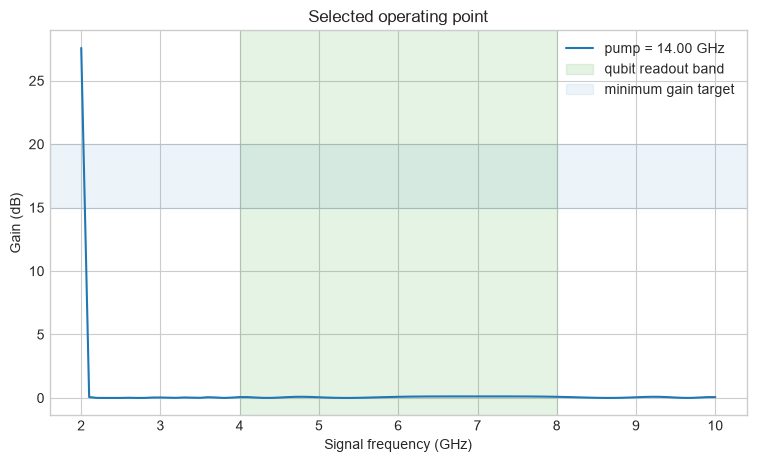

Best metrics: {'band_GHz': [4.0, 8.0], 'peak_gain_db': 27.581881911546375, 'peak_frequency_GHz': 2.0, 'mean_in_band_gain_db': 0.07720738813535198, 'median_in_band_gain_db': 0.08922952707345035, 'ripple_peak_to_peak_db': 0.11825051422572065, 'ripple_std_db': 0.04205305891719381, 'fraction_above_15db': 0.0, 'fraction_above_17db': 0.0, 'fraction_above_20db': 0.0, 'bandwidth_regions_GHz': [(2.0, 2.0)], 'total_3db_bandwidth_GHz': 0.10000000000000009, 'finite': True, 'pump_GHz': 13.999999999999995}
Amplifier checks: {'finite_gain': True, 'mean_4to8_gain_at_least_15db': False, 'at_least_80pct_above_17db': False, 'ripple_no_more_than_3db': True, 'pump_outside_4to8_GHz': True}
READY FOR HARDWARE REVIEW: False


In [5]:
band = tuple(config["readout_band_GHz"])
metrics_by_pump = []
for pump, row in zip(pumps, gain_map):
    metrics = gain_metrics(signals, row, band=band)
    metrics["pump_GHz"] = float(pump)
    metrics_by_pump.append(metrics)

best = max(
    metrics_by_pump,
    key=lambda item: (
        item["fraction_above_17db"],
        item["mean_in_band_gain_db"],
        -item["ripple_peak_to_peak_db"],
    ),
)
best_index = int(np.argmin(abs(pumps - best["pump_GHz"])))
best_gain = gain_map[best_index]

amplifier_checks = {
    "finite_gain": bool(best["finite"]),
    "mean_4to8_gain_at_least_15db": best["mean_in_band_gain_db"] >= 15,
    "at_least_80pct_above_17db": best["fraction_above_17db"] >= 0.8,
    "ripple_no_more_than_3db": best["ripple_peak_to_peak_db"] <= 3,
    "pump_outside_4to8_GHz": not (4 <= best["pump_GHz"] <= 8),
}
hfss_ready = provenance["cell_input"]["all_hfss_acceptance_checks_pass"]
amplifier_ready = all(amplifier_checks.values())
ready_for_hardware_review = bool(hfss_ready and amplifier_ready)

summary = {
    "input_status": provenance["status"],
    "mixing_process": process,
    "total_cells": twpa.N_tot,
    "best_operating_point": best,
    "pump_current_A": twpa.Ip0,
    "pump_power_50ohm_dbm": float(current_to_dbm(twpa.Ip0)),
    "dc_current_A": twpa.Idc,
    "hfss_checks": provenance["cell_input"]["acceptance_checks"],
    "amplifier_checks": amplifier_checks,
    "ready_for_hardware_review": ready_for_hardware_review,
    "not_simulated": [
        "quantum noise", "qubit fidelity", "package and launch",
        "fabrication variation", "cryogenic measurement chain",
    ],
}
save_json(OUT / "04_amplifier_assessment.json", summary)
save_curve(OUT / "04_selected_gain.csv", frequency_GHz=signals, gain_db=best_gain)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(signals, best_gain, label=f"pump = {best['pump_GHz']:.2f} GHz")
ax.axvspan(4, 8, color="C2", alpha=0.12, label="qubit readout band")
ax.axhspan(15, 20, color="C0", alpha=0.08, label="minimum gain target")
ax.set(xlabel="Signal frequency (GHz)", ylabel="Gain (dB)", title="Selected operating point")
ax.legend()
save_figure(fig, OUT, "04_selected_operating_point")
plt.show()

print("Best metrics:", best)
print("Amplifier checks:", amplifier_checks)
print("READY FOR HARDWARE REVIEW:", ready_for_hardware_review)
if not provenance["cell_input"]["hfss_validated"]:
    print("Expected result for the template: FALSE, because no HFSS data have been imported.")

## HFSS handoff used by this run

1. The 12 µm and 3.9 µm kinetic-sheet Touchstone sweeps were exported from HFSS.
2. `scripts/fit_hfss_unit_cells.py` fitted `L`, `C`, and `Lf` over 4–14 GHz.
3. The fitted rows are stored in `hfss_cell_parameters.csv` with `source=HFSS`.
4. This notebook uses those rows with `ALLOW_PLACEHOLDER=False`.
5. Re-run the fitting script before this notebook whenever HFSS data change.

A `True` hardware-review result means the circuit and HFSS gates passed. It is
not permission to fabricate without package, tolerance, and cryogenic review.